In [1]:
import random
import textwrap

In [2]:
def generate_genome(length, seed=None):
    if seed is not None:
        random.seed(seed)
    bases = ["A", "T", "C", "G"]
    return "".join(random.choices(bases, k=length))

def write_fasta(sequence, output_path, header=">simulated_genome", line_width=80):
    with open(output_path, "w") as f:
        f.write(f"{header}\n")
        for line in textwrap.wrap(sequence, line_width):
            f.write(line + "\n")

## Generate genomes

In [3]:
# genome_lengths = [500, 1000, 2500, 5000, 10000, 25000, 50000, 100000, 250000, 500000, 1000000, 2500000, 5000000]
# for leng in genome_lengths:
#     write_fasta(generate_genome(leng), f"data/random_genomes/{leng}.fasta", f">{leng}")

## Generate 10000x sequencing data for each of those

Wouldn't recommend running this again.. (takes ~15 min)

I repeated this with 1000x, 5000x, and 10000x

In [4]:
# import argparse
# from pathlib import Path
# import glob
# import os

# READ_LEN = 250
# COVERAGE = 30000

# def read_fasta(path):
#     seq = []
#     with open(path) as f:
#         for line in f:
#             if not line.startswith(">"):
#                 seq.append(line.strip())
#     return "".join(seq)

# def write_fastq(genome, output_path):
#     G = len(genome)
#     total_bases = G * COVERAGE
#     n_reads = total_bases // READ_LEN  # exactly 40*G

#     with open(output_path, "w") as out:
#         for i in range(n_reads):
#             start = (i * READ_LEN) % G
#             read = genome[start:start + READ_LEN]

#             # wrap circularly if needed
#             if len(read) < READ_LEN:
#                 read += genome[:READ_LEN - len(read)]

#             out.write(f"@read_{i}\n")
#             out.write(read + "\n")
#             out.write("+\n")
#             out.write("I" * READ_LEN + "\n")  # perfect quality

# for genome in glob.glob("data/random_genomes/*.fasta"):
#     genome_data = read_fasta(genome)
#     name = os.path.splitext(os.path.basename(genome))[0]
#     write_fastq(genome_data, f"data/random_genome_seq_data/{COVERAGE}x/{name}.fastq")

## Run benchmark

Run this in the `benchmark_build.py` file

## Plotting output

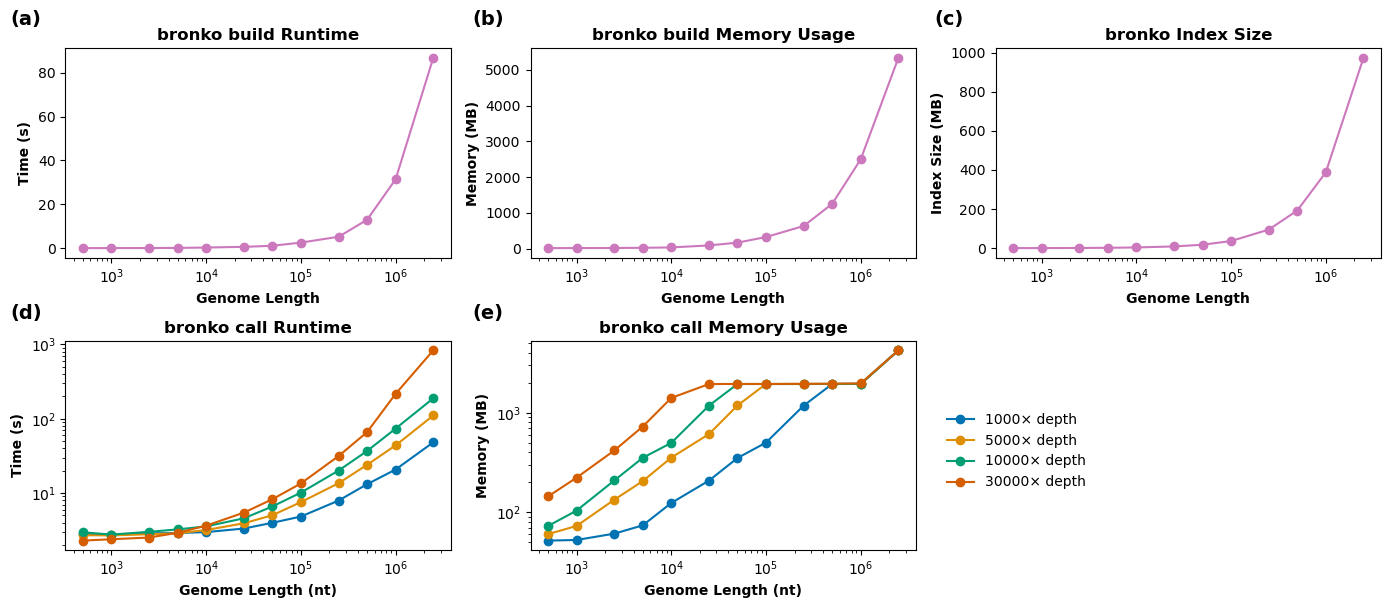

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns

CSV_FILE = "benchmark_results.csv"

base_palette = sns.color_palette("colorblind", n_colors=8)

def parse_time_to_seconds(t):
    parts = t.split(":")
    parts = [float(p) for p in parts]
    if len(parts) == 2:
        return parts[0] * 60 + parts[1]
    elif len(parts) == 3:
        return parts[0] * 3600 + parts[1] * 60 + parts[2]
    return None

def extract_genome_size(filename):
    match = re.search(r"(\d+)", filename)
    return int(match.group(1)) if match else None

df = pd.read_csv(CSV_FILE)

df["time_sec"] = df["elapsed_time"].apply(parse_time_to_seconds)
df["memory_mb"] = df["max_rss_kb"] / 1024
df["genome_size"] = df["file"].apply(extract_genome_size)

df = df.sort_values("genome_size")

metrics = ["time_sec", "memory_mb", "index_mb"]
titles = ["Bronko Build Time", "Bronko Build Memory Usage", "Index Size"]

INDEX_CSV = "benchmark_index_size.csv"

df_index = pd.read_csv(INDEX_CSV)
df_index["genome_size"] = df_index["file"].apply(extract_genome_size)
df_index["index_mb"] = df_index["index_size_kB"] / 1024
df_index = df_index.sort_values("genome_size")

CALL_FILES = [
    "benchmark_results_call_1000.csv",
    "benchmark_results_call_5000.csv",
    "benchmark_results_call_10000.csv",
    "benchmark_results_call_30000.csv"
]

call_dfs = {}

for file in CALL_FILES:
    depth = re.search(r"_(\d+)\.csv", file).group(1)

    df_tmp = pd.read_csv(file)
    df_tmp["time_sec"] = df_tmp["elapsed_time"].apply(parse_time_to_seconds)
    df_tmp["memory_mb"] = df_tmp["max_rss_kb"] / 1024
    df_tmp = df_tmp.sort_values("genome_size")

    call_dfs[depth] = df_tmp

fig, axes = plt.subplots(2, 3, figsize=(14, 6))


# -------- TOP ROW (BUILD) --------
build_metrics = ["time_sec", "memory_mb"]
build_titles = ["bronko build Runtime", "bronko build Memory Usage", "bronko Index Size"]

for col in range(3):

    ax = axes[0, col]

    if col == 0:
        xvals = df["genome_size"]
        yvals = df["time_sec"]
        ax.set_ylabel("Time (s)", fontweight="bold")

    elif col == 1:
        xvals = df["genome_size"]
        yvals = df["memory_mb"]
        ax.set_ylabel("Memory (MB)", fontweight="bold")

    else:
        xvals = df_index["genome_size"]
        yvals = df_index["index_mb"]
        ax.set_ylabel("Index Size (MB)", fontweight="bold")

    ax.plot(xvals, yvals, marker="o", color=base_palette[4])
    ax.set_xscale("log")
    ax.set_title(build_titles[col], fontweight="bold")
    ax.set_xlabel("Genome Length", fontweight="bold")


# -------- BOTTOM ROW (CALL) --------
call_titles = ["bronko call Runtime", "bronko call Memory Usage"]

call_palette = sns.color_palette("colorblind", n_colors=len(call_dfs))

for col in range(2):

    ax = axes[1, col]

    for i, (depth, df_call) in enumerate(sorted(call_dfs.items(), key=lambda x: int(x[0]))):

        xvals = df_call["genome_size"]

        if col == 0:
            yvals = df_call["time_sec"]
            ax.set_ylabel("Time (s)", fontweight="bold")
        else:
            yvals = df_call["memory_mb"]
            ax.set_ylabel("Memory (MB)", fontweight="bold")

        ax.plot(
            xvals,
            yvals,
            marker="o",
            color=call_palette[i],
            label=f"{depth}× depth"
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(call_titles[col], fontweight="bold")
    ax.set_xlabel("Genome Length (nt)", fontweight="bold")
    
axes[1, 2].axis("off")
        
handles, labels = axes[1, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.67, 0.27),
    frameon=False
)
# axes[0][0].set_ylabel('Time (s)')
# axes[0][1].set_ylabel('Memory Used (MB)')
# axes[0][2].set_ylabel('Index Size (MB)')

fig.text(0.01, 0.98, '(a)', fontsize=14, fontweight='bold')
fig.text(0.34, 0.98, '(b)', fontsize=14, fontweight='bold')
fig.text(0.67, 0.98, '(c)', fontsize=14, fontweight='bold')

fig.text(0.01, 0.49, '(d)', fontsize=14, fontweight='bold')
fig.text(0.34, 0.49, '(e)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("../figures/Supp_1.pdf", bbox_inches="tight", dpi=600)
plt.savefig("../figures/Supp_1.svg", bbox_inches="tight", dpi=600)
plt.savefig("../figures/Supp_1.png", bbox_inches="tight", dpi=600)
plt.show()


# Part 2 -- Integrating more genomes

I primarily use the sars-cov-2 genomes I downloaded. Going from 0-100

First run the `benchmark_build_sars.py`

In [ ]:
# READ_LEN = 250
# COVERAGE = 5000

# def read_fasta(path):
#     seq = []
#     with open(path) as f:
#         for line in f:
#             if not line.startswith(">"):
#                 seq.append(line.strip())
#     return "".join(seq)

# def write_fastq(genome, output_path, coverage):
#     G = len(genome)
#     total_bases = G * coverage
#     n_reads = total_bases // READ_LEN  # exactly 40*G

#     with open(output_path, "w") as out:
#         for i in range(n_reads):
#             start = (i * READ_LEN) % G
#             read = genome[start:start + READ_LEN]

#             # wrap circularly if needed
#             if len(read) < READ_LEN:
#                 read += genome[:READ_LEN - len(read)]

#             out.write(f"@read_{i}\n")
#             out.write(read + "\n")
#             out.write("+\n")
#             out.write("I" * READ_LEN + "\n")  # perfect quality
# for cover in [1000, 5000, 10000, 30000]:
#     write_fastq(read_fasta("/home/Users/rdd4/bronko-test/bronko_test/build_benchmark/data/sars_genomes/BS007334.1.fasta"), f"data/sars_genome_seq_data/{cover}.fastq", cover)

Then run `benchmark_call_sars.py`

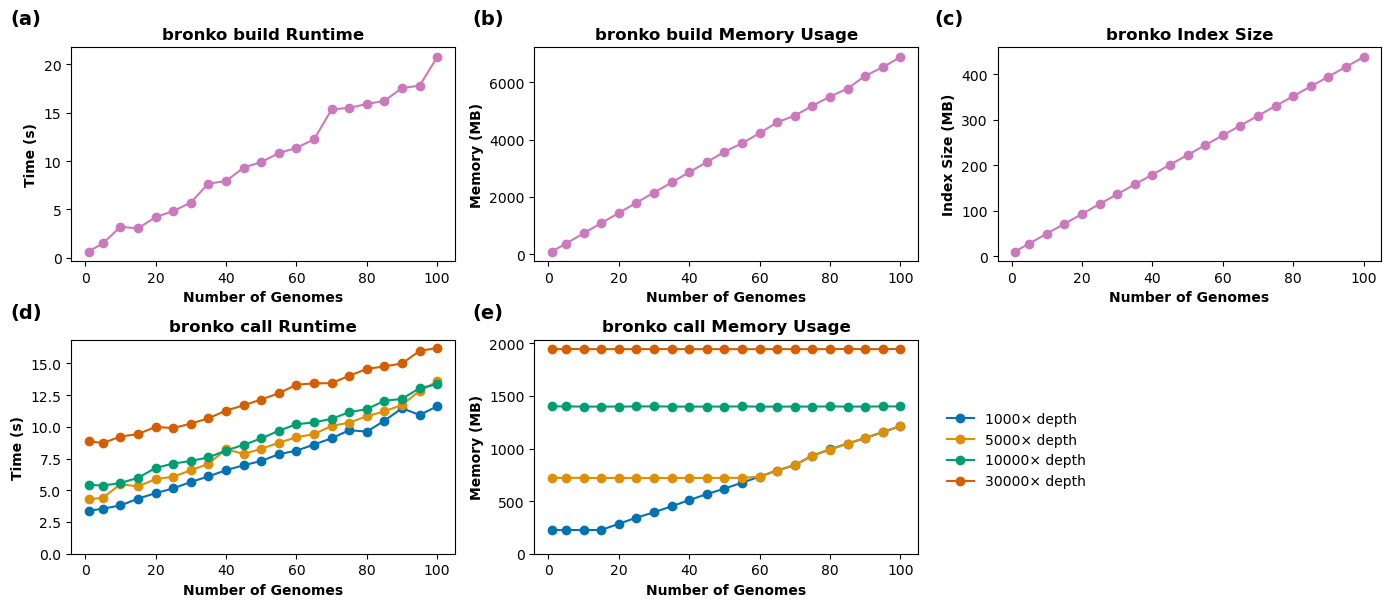

In [79]:
CSV_FILE = "benchmark_results_sars.csv"

base_palette = sns.color_palette("colorblind", n_colors=8)

def parse_time_to_seconds(t):
    parts = t.split(":")
    parts = [float(p) for p in parts]
    if len(parts) == 2:
        return parts[0] * 60 + parts[1]
    elif len(parts) == 3:
        return parts[0] * 3600 + parts[1] * 60 + parts[2]
    return None

def extract_genome_size(filename):
    match = re.search(r"(\d+)", filename)
    return int(match.group(1)) if match else None

df = pd.read_csv(CSV_FILE)

df["time_sec"] = df["elapsed_time"].apply(parse_time_to_seconds)
df["memory_mb"] = df["max_rss_kb"] / 1024

df = df.sort_values("number_files")

metrics = ["time_sec", "memory_mb", "index_mb"]
titles = ["Bronko Build Time", "Bronko Build Memory Usage", "Index Size"]

INDEX_CSV = "benchmark_index_size_sars.csv"

df_index = pd.read_csv(INDEX_CSV)
df_index["number_files"] = df_index["file"].apply(extract_genome_size)
df_index["index_mb"] = df_index["index_size_kB"] / 1024
df_index = df_index.sort_values("number_files")

CALL_FILES = [
    "benchmark_results_call_sars_1000.csv",
    "benchmark_results_call_sars_5000.csv",
    "benchmark_results_call_sars_10000.csv",
    "benchmark_results_call_sars_30000.csv"]

call_dfs = {}

for file in CALL_FILES:
    depth = re.search(r"_(\d+)\.csv", file).group(1)

    df_tmp = pd.read_csv(file)
    df_tmp["time_sec"] = df_tmp["elapsed_time"].apply(parse_time_to_seconds)
    df_tmp["memory_mb"] = df_tmp["max_rss_kb"] / 1024
    df_tmp = df_tmp.sort_values("number_files")

    call_dfs[depth] = df_tmp

fig, axes = plt.subplots(2, 3, figsize=(14, 6))


# -------- TOP ROW (BUILD) --------
build_metrics = ["time_sec", "memory_mb"]
build_titles = ["bronko build Runtime", "bronko build Memory Usage", "bronko Index Size"]

for col in range(3):

    ax = axes[0, col]

    if col == 0:
        xvals = df["number_files"]
        yvals = df["time_sec"]
        ax.set_ylabel("Time (s)", fontweight="bold")

    elif col == 1:
        xvals = df["number_files"]
        yvals = df["memory_mb"]
        ax.set_ylabel("Memory (MB)", fontweight="bold")

    else:
        xvals = df_index["number_files"]
        yvals = df_index["index_mb"]
        ax.set_ylabel("Index Size (MB)", fontweight="bold")

    ax.plot(xvals, yvals, marker="o", color=base_palette[4])
    ax.set_title(build_titles[col], fontweight="bold")
    ax.set_xlabel("Number of Genomes", fontweight="bold")


# -------- BOTTOM ROW (CALL) --------
call_titles = ["bronko call Runtime", "bronko call Memory Usage"]

call_palette = sns.color_palette("colorblind", n_colors=len(call_dfs))

for col in range(2):

    ax = axes[1, col]

    for i, (depth, df_call) in enumerate(sorted(call_dfs.items(), key=lambda x: int(x[0]))):

        xvals = df_call["number_files"]

        if col == 0:
            yvals = df_call["time_sec"]
            ax.set_ylabel("Time (s)", fontweight="bold")
        else:
            yvals = df_call["memory_mb"]
            ax.set_ylabel("Memory (MB)", fontweight="bold")

        ax.plot(
            xvals,
            yvals,
            marker="o",
            color=call_palette[i],
            label=f"{depth}× depth"
        )

    ax.set_title(call_titles[col], fontweight="bold")
    ax.set_xlabel("Number of Genomes", fontweight="bold")
    ax.set_ylim(bottom=0)
    
axes[1, 2].axis("off")
        
handles, labels = axes[1, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.67, 0.27),
    frameon=False
)
# axes[0][0].set_ylabel('Time (s)')
# axes[0][1].set_ylabel('Memory Used (MB)')
# axes[0][2].set_ylabel('Index Size (MB)')

fig.text(0.01, 0.98, '(a)', fontsize=14, fontweight='bold')
fig.text(0.34, 0.98, '(b)', fontsize=14, fontweight='bold')
fig.text(0.67, 0.98, '(c)', fontsize=14, fontweight='bold')

fig.text(0.01, 0.49, '(d)', fontsize=14, fontweight='bold')
fig.text(0.34, 0.49, '(e)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig("../figures/Supp_2.pdf", bbox_inches="tight", dpi=600)
plt.savefig("../figures/Supp_2.svg", bbox_inches="tight", dpi=600)
plt.savefig("../figures/Supp_2.png", bbox_inches="tight", dpi=600)
plt.show()